# 05 · One-to-Many — Generating Sequences with an Autoregressive RNN

So far our RNNs **consumed** sequences and produced a single answer (many-to-one, notebook 04).
Now we flip the arrow: from a small seed we **produce a whole sequence**, one element at a time.
This is the **one-to-many / generative** pattern behind text generation, music generation, and —
the modern descendant — the language models you use every day (which are Transformers, but share
this exact *autoregressive* generation idea).

We'll build a **character-level name generator**: train an LSTM on a list of real names, then let
it invent **new, plausible-sounding names**. It's small, fast, and the results are fun and easy to
judge by eye.

## The plan, in one breath

One architecture — `CharGenerator` (embedding → LSTM → linear head) — used two ways:

- **Training (Sections 4–5):** show the model full names and make it predict the next character
  at every position (*many-to-many*). There are **two paradigms** for pushing a sequence through
  an RNN — whole-sequence-in-one-call vs. one-char-per-call with the memory carried by hand. We
  first define both side by side, then **train with both and measure the trade-offs**.
- **Generation (Section 6):** seed with `.`, sample a character, feed it back, repeat
  (*one-to-many / autoregressive*) — which, as we'll see, *forces* the one-char-per-call shape.


## Roadmap

1. **Section 1** — The data: names → integer tokens with a **vocabulary**.
2. **Section 2** — Turning names into training pairs (**next-character prediction**, input shifted by one).
3. **Section 3** — The model: **embeddings**, and why ONE class serves every call shape
   (whole sequence or one char at a time).
4. **Section 4** — The two paradigms for moving memory through time: 📖 the **Golden Rule**
   (stateless vs. stateful), precise definitions, the **pros/cons table**, and a **side-by-side
   diagram** of where memory & gradients flow.
5. **Section 5** — Train the generator with **BOTH** paradigms and *measure* the difference
   (wall-clock, loss curves, sample quality).
6. **Section 6** — Generate: **autoregression** + the **temperature** knob (creativity vs. safety).
7. **Sections 7–8** — How this exact machinery scales up to modern LLMs, and recap.

You'll learn:
1. How to turn text into integer tokens with a **vocabulary**.
2. The **two paradigms of moving memory through time** — `seq_len = max` vs `seq_len = 1` +
   memory forward — and their trade-offs (gradient reach, speed, memory, code complexity).
3. The subtle but crucial point: we **train** the model as *many-to-many* (predict the next
   character at every position), but we **use** it as *one-to-many* (feed its own output back in).
4. **Embeddings** — a learned lookup table that replaces clumsy one-hot vectors.
5. **Sampling** and the **temperature** knob that controls creativity vs. safety.


In [85]:
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
import matplotlib.pyplot as plt

torch.manual_seed(0); np.random.seed(0)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("device:", device)

device: cpu


## 1. The data: a list of names

We embed a corpus of names directly so the notebook is fully self-contained (no downloads). The
model will learn the *statistics of letter sequences* in these names — which letters tend to
start a name, common endings like "-ia" or "-on", plausible consonant/vowel patterns — and use
that to generate new ones.

In [86]:
names = [
    "amelia","oliver","sophia","liam","emma","noah","ava","william","isabella","james",
    "mia","benjamin","charlotte","lucas","amara","henry","evelyn","alexander","harper","daniel",
    "elena","gabriel","aurora","samuel","luna","david","chloe","joseph","layla","matthew",
    "penelope","julian","nora","leo","hazel","adrian","violet","aaron","stella","nathan",
    "maria","antonio","lucia","marco","sofia","diego","valentina","mateo","camila","sebastian",
    "isabel","andres","carmen","pablo","elsa","victor","adriana","emilio","natalia","hugo",
    "olivia","ethan","abigail","jacob","emily","michael","elizabeth","daniel","grace","logan",
    "clara","ivan","laura","oscar","paula","ruben","teresa","alvaro","irene","javier",
    "rosa","felix","alba","bruno","noa","alma","dario","vera","enzo","nadia",
    "ana","luis","marta","jorge","sara","raul","elisa","cesar","julia","angel",
]
names = sorted(set(names))
print(f"{len(names)} names, e.g.:", names[:8])

# --- build the vocabulary (character <-> integer) ---
# We add two SPECIAL tokens:  '.' marks the END of a name (so the model learns when to stop),
# and it doubles as the START token we feed to kick off generation.
chars = ["."] + sorted(set("".join(names)))
stoi = {c: i for i, c in enumerate(chars)}   # string -> index
itos = {i: c for c, i in stoi.items()}       # index  -> string
VOCAB = len(chars)
print("vocabulary size:", VOCAB) # number of unique characters
print("char->index map:", stoi) 

99 names, e.g.: ['aaron', 'abigail', 'adrian', 'adriana', 'alba', 'alexander', 'alma', 'alvaro']
vocabulary size: 25
char->index map: {'.': 0, 'a': 1, 'b': 2, 'c': 3, 'd': 4, 'e': 5, 'f': 6, 'g': 7, 'h': 8, 'i': 9, 'j': 10, 'l': 11, 'm': 12, 'n': 13, 'o': 14, 'p': 15, 'r': 16, 's': 17, 't': 18, 'u': 19, 'v': 20, 'w': 21, 'x': 22, 'y': 23, 'z': 24}


## 2. Turning names into training pairs

Key idea — **next-character prediction.** For the name `ana`, we frame it as: given what we've
seen so far, predict the next character. We wrap each name with the special `.` token at both ends:

```
input :  .  a  n  a
target:  a  n  a  .
```

So at every position the target is simply the **input shifted left by one**. Training the model to
predict the next character at *every* position is a **many-to-many (aligned)** setup — and it's
far more efficient than predicting only the final character, because every position contributes a
learning signal.

Those dots act as special Start-of-Sequence (SOS) and End-of-Sequence (EOS) tokens.

Here is exactly why they are shifted like that:

In a standard many-to-many RNN, the model processes the data step-by-step (character by character). At every single step, it takes an input character and tries to predict the next character.

An RNN cannot predict something out of thin air; it always needs an input to kick off its mathematical calculations. If you didn't have the starting dot, what would you feed the network at Time Step 1 to get it to predict the first letter "n"? You'd have nothing. The leading dot acts as a "Go!" signal. It tells the network: "Hey, we are starting a brand new name now, give me a likely first letter."

In [87]:
def encode_name(name):
    '''Return (input_ids, target_ids) for one name, using '.' as start & end marker.'''
    tokens = [stoi["."]] + [stoi[c] for c in name] + [stoi["."]]
    x = tokens[:-1]     # everything except the last  -> inputs
    y = tokens[1:]      # everything except the first -> targets (shifted by one)
    return x, y

xi, yi = encode_name("ana")
print("name 'ana' becomes:")
print("  input tokens :", xi, "->", [itos[i] for i in xi])
print("  target tokens:", yi, "->", [itos[i] for i in yi])
print("\nAt each step the model must predict the NEXT character (the target).")

# Because names have different lengths, we PAD each sequence to the longest, and remember the
# real length so padding doesn't pollute the loss.
encoded = [encode_name(n) for n in names]
maxlen = max(len(x) for x, _ in encoded)

X = torch.full((len(names), maxlen), stoi["."], dtype=torch.long) # we fill the gaps with the PAD token ('.')
Y = torch.full((len(names), maxlen), stoi["."], dtype=torch.long)
lengths = []
for i, (x, y) in enumerate(encoded):
    X[i, :len(x)] = torch.tensor(x)
    Y[i, :len(y)] = torch.tensor(y)
    lengths.append(len(x))
lengths = torch.tensor(lengths)
print("\nX shape (names, maxlen):", tuple(X.shape))

name 'ana' becomes:
  input tokens : [0, 1, 13, 1] -> ['.', 'a', 'n', 'a']
  target tokens: [1, 13, 1, 0] -> ['a', 'n', 'a', '.']

At each step the model must predict the NEXT character (the target).

X shape (names, maxlen): (99, 10)


In [88]:
X[:5] # 0 means ".", at the end we can see more than one "." because of padding

tensor([[ 0,  1,  1, 16, 14, 13,  0,  0,  0,  0],
        [ 0,  1,  2,  9,  7,  1,  9, 11,  0,  0],
        [ 0,  1,  4, 16,  9,  1, 13,  0,  0,  0],
        [ 0,  1,  4, 16,  9,  1, 13,  1,  0,  0],
        [ 0,  1, 11,  2,  1,  0,  0,  0,  0,  0]])

In [89]:
Y[:5]

tensor([[ 1,  1, 16, 14, 13,  0,  0,  0,  0,  0],
        [ 1,  2,  9,  7,  1,  9, 11,  0,  0,  0],
        [ 1,  4, 16,  9,  1, 13,  0,  0,  0,  0],
        [ 1,  4, 16,  9,  1, 13,  1,  0,  0,  0],
        [ 1, 11,  2,  1,  0,  0,  0,  0,  0,  0]])

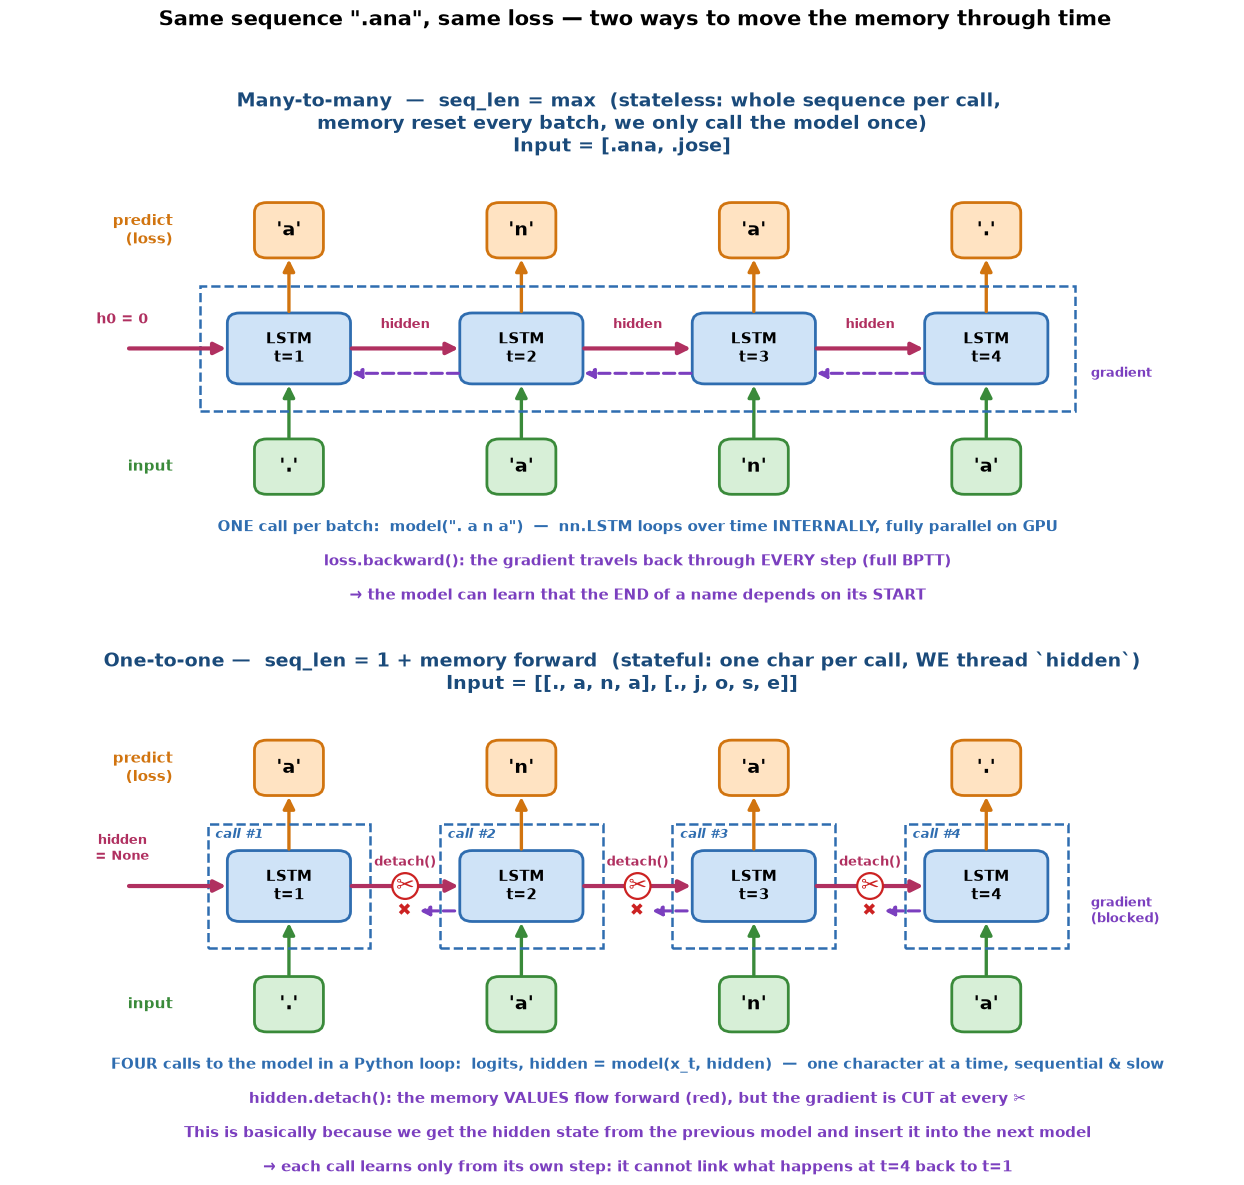

In [98]:
# --- The two paradigms side by side (run this cell) -----------------------------------
# Same sequence ".ana", same per-step losses. What differs:
#   TOP    (Many-to-many 1, seq_len=max):     ONE model call; nn.LSTM threads `hidden` internally;
#                                         the gradient (purple) travels back through EVERY step.
#   BOTTOM (One-to-one 2, seq_len=1+fwd):   FOUR calls; WE thread `hidden` between them;
#                                         detach() lets the memory VALUES pass (red) but CUTS
#                                         the gradient at every ✂ -> each step learns alone.
from matplotlib.patches import FancyBboxPatch, FancyArrowPatch, Rectangle

p_inputs  = [".", "a", "n", "a"]
p_targets = ["a", "n", "a", "."]
p_n = len(p_inputs)
p_xs = [0, 3.0, 6.0, 9.0]
P_BW, P_BH = 1.55, 1.1
P_TW, P_TH = 0.85, 0.85
P_Y_IN, P_Y_MODEL, P_Y_OUT = -1.9, 0.0, 1.9
PC_MODEL, PC_MODEL_E = "#cfe3f7", "#2f6db0"
PC_IN,    PC_IN_E    = "#d7efd7", "#3a8a3a"
PC_OUT,   PC_OUT_E   = "#ffe3c2", "#d1740f"
PC_HID, PC_GRAD, PC_CUT = "#b03060", "#7b3fbf", "#cc2222"

fig, axes = plt.subplots(2, 1, figsize=(13, 12))

def p_rbox(ax, x, y, w, h, fc, ec, text, fs=12):
    ax.add_patch(FancyBboxPatch((x - w/2, y - h/2), w, h,
                 boxstyle="round,pad=0.02,rounding_size=0.16", fc=fc, ec=ec, lw=2))
    ax.text(x, y, text, ha="center", va="center", fontsize=fs, fontweight="bold")

def p_arrow(ax, p0, p1, color, lw=2.4, ls="solid", ms=17):
    ax.add_patch(FancyArrowPatch(p0, p1, arrowstyle="-|>", mutation_scale=ms,
                 lw=lw, color=color, linestyle=ls))

def p_steps(ax):
    for i, x in enumerate(p_xs):
        p_rbox(ax, x, P_Y_MODEL, P_BW, P_BH, PC_MODEL, PC_MODEL_E, f"LSTM\nt={i+1}", fs=11)
        p_rbox(ax, x, P_Y_IN, P_TW, P_TH, PC_IN, PC_IN_E, f"'{p_inputs[i]}'", fs=14)
        p_arrow(ax, (x, P_Y_IN + P_TH/2), (x, P_Y_MODEL - P_BH/2), PC_IN_E)
        p_rbox(ax, x, P_Y_OUT, P_TW, P_TH, PC_OUT, PC_OUT_E, f"'{p_targets[i]}'", fs=14)
        p_arrow(ax, (x, P_Y_MODEL + P_BH/2), (x, P_Y_OUT - P_TH/2), PC_OUT_E)
    ax.text(p_xs[0] - 1.5, P_Y_IN, "input", ha="right", va="center", fontsize=11, color=PC_IN_E, fontweight="bold")
    ax.text(p_xs[0] - 1.5, P_Y_OUT, "predict\n(loss)", ha="right", va="center", fontsize=11, color=PC_OUT_E, fontweight="bold")

def p_caption(ax, lines_colors):
    y = -2.75
    for text, color in lines_colors:
        ax.text((p_xs[0] + p_xs[-1]) / 2, y, text, ha="center", va="top",
                fontsize=11, color=color, fontweight="bold")
        y -= 0.55

# ------------------------------ TOP: Many-to-many 1 ------------------------------
ax = axes[0]
p_steps(ax)
ax.add_patch(Rectangle((p_xs[0] - 1.15, P_Y_MODEL - 1.0), (p_xs[-1] - p_xs[0]) + 2.3, 2.0,
             fill=False, ec=PC_MODEL_E, lw=1.8, ls="dashed"))          # ONE call = one container
p_arrow(ax, (p_xs[0] - 2.1, P_Y_MODEL), (p_xs[0] - P_BW/2, P_Y_MODEL), PC_HID, lw=3)
ax.text(p_xs[0] - 2.15, P_Y_MODEL + 0.35, "h0 = 0", ha="center", va="bottom", fontsize=10, color=PC_HID, fontweight="bold")
for i in range(p_n - 1):
    p_arrow(ax, (p_xs[i] + P_BW/2, P_Y_MODEL), (p_xs[i+1] - P_BW/2, P_Y_MODEL), PC_HID, lw=3)
    ax.text((p_xs[i] + p_xs[i+1]) / 2, P_Y_MODEL + 0.28, "hidden", ha="center", va="bottom",
            fontsize=9, color=PC_HID, fontweight="bold")
for i in range(p_n - 1, 0, -1):                                        # gradient: back through ALL steps
    p_arrow(ax, (p_xs[i] - P_BW/2, P_Y_MODEL - 0.40), (p_xs[i-1] + P_BW/2, P_Y_MODEL - 0.40),
            PC_GRAD, lw=2.2, ls="dashed", ms=14)
ax.text(p_xs[-1] + 1.35, P_Y_MODEL - 0.40, "gradient", ha="left", va="center", fontsize=9.5, color=PC_GRAD, fontweight="bold")
p_caption(ax, [
    ('ONE call per batch:  model(". a n a")  —  nn.LSTM loops over time INTERNALLY, fully parallel on GPU', PC_MODEL_E),
    ("loss.backward(): the gradient travels back through EVERY step (full BPTT)", PC_GRAD),
    ("→ the model can learn that the END of a name depends on its START", PC_GRAD),
])
ax.set_title("Many-to-many  —  seq_len = max  (stateless: whole sequence per call, \nmemory reset every batch, we only call the model once)"
             "\nInput = [.ana, .jose]",
             fontsize=13.5, fontweight="bold", pad=12, color="#1a4a7a")
ax.set_xlim(p_xs[0] - 3.6, p_xs[-1] + 3.2); ax.set_ylim(-4.6, 2.9); ax.axis("off")

# ---------------------------- BOTTOM: One-to-one 2 ----------------------------
ax = axes[1]
p_steps(ax)
for i, x in enumerate(p_xs):                                           # each step = its OWN call/container
    ax.add_patch(Rectangle((x - 1.05, P_Y_MODEL - 1.0), 2.1, 2.0,
                 fill=False, ec=PC_MODEL_E, lw=1.8, ls="dashed"))
    ax.text(x - 0.95, P_Y_MODEL + 0.83, f"call #{i+1}", ha="left", va="center",
            fontsize=9, color=PC_MODEL_E, fontweight="bold", style="italic")
p_arrow(ax, (p_xs[0] - 2.1, P_Y_MODEL), (p_xs[0] - P_BW/2, P_Y_MODEL), PC_HID, lw=3)
ax.text(p_xs[0] - 2.15, P_Y_MODEL + 0.35, "hidden\n= None", ha="center", va="bottom", fontsize=9.5, color=PC_HID, fontweight="bold")
for i in range(p_n - 1):
    xm = (p_xs[i] + p_xs[i+1]) / 2
    p_arrow(ax, (p_xs[i] + P_BW/2, P_Y_MODEL), (p_xs[i+1] - P_BW/2, P_Y_MODEL), PC_HID, lw=3)
    ax.text(xm, P_Y_MODEL + 0.28, "detach()", ha="center", va="bottom", fontsize=9, color=PC_HID, fontweight="bold")
    ax.text(xm, P_Y_MODEL, "✂", ha="center", va="center", fontsize=16, color=PC_CUT, fontweight="bold",
            zorder=5, bbox=dict(boxstyle="circle,pad=0.08", fc="white", ec=PC_CUT, lw=1.6))
for i in range(1, p_n):                                                # gradient: dies at the call boundary
    p_arrow(ax, (p_xs[i] - P_BW/2 - 0.05, P_Y_MODEL - 0.40), (p_xs[i] - 1.35, P_Y_MODEL - 0.40),
            PC_GRAD, lw=2.2, ls="dashed", ms=14)
    ax.text(p_xs[i] - 1.42, P_Y_MODEL - 0.40, "✖", ha="right", va="center", fontsize=12, color=PC_CUT, fontweight="bold")
ax.text(p_xs[-1] + 1.35, P_Y_MODEL - 0.40, "gradient\n(blocked)", ha="left", va="center", fontsize=9.5, color=PC_GRAD, fontweight="bold")
p_caption(ax, [
    ("FOUR calls to the model in a Python loop:  logits, hidden = model(x_t, hidden)  —  one character at a time, sequential & slow", PC_MODEL_E),
    ("hidden.detach(): the memory VALUES flow forward (red), but the gradient is CUT at every ✂", PC_GRAD),
    ("This is basically because we get the hidden state from the previous model and insert it into the next model", PC_GRAD),
    ("→ each call learns only from its own step: it cannot link what happens at t=4 back to t=1", PC_GRAD),
])
ax.set_title("One-to-one —  seq_len = 1 + memory forward  (stateful: one char per call, WE thread `hidden`)"
             "\nInput = [[., a, n, a], [., j, o, s, e]]",
             fontsize=13.5, fontweight="bold", pad=12, color="#1a4a7a")
ax.set_xlim(p_xs[0] - 3.6, p_xs[-1] + 3.2); ax.set_ylim(-4.6, 2.9); ax.axis("off")

fig.suptitle('Same sequence ".ana", same loss — two ways to move the memory through time',
             fontsize=15, fontweight="bold", y=0.985)
plt.tight_layout(rect=[0, 0, 1, 0.96]); plt.show()

## 3. Embeddings: a better way to feed characters

A character is a *category*, not a number — "c" (index 3) isn't "three times" the start token.
Two ways to feed categories to a network:

- **One-hot vectors** — a length-`VOCAB` vector of zeros with a single 1. Wasteful and carries no
  notion of similarity between characters.
- **Embeddings** *(what we use)* — a small **learned lookup table** mapping each character id to a
  dense vector (say 16 numbers). During training the model arranges this table so that characters
  used in similar contexts end up with similar vectors. `nn.Embedding` does exactly this.

Embeddings are the standard first layer for *any* categorical/token input — words, product ids,
user ids — so this pattern generalizes far beyond names.

### One model serves every call shape

Before writing the class, notice what its `forward(self, x, hidden=None)` signature must allow —
because we are going to call the SAME model in different ways later:

| Detail of the signature | What it allows |
|---|---|
| `x` can have **any** time length — `nn.LSTM` doesn't care if it gets `(batch, maxlen)` or `(batch, 1)` | whole-name calls **and** one-char calls |
| `hidden` is **optional** — `None` means "start with a blank memory" | fresh starts **and** continuing exactly where a previous call left off |
| it **returns `hidden`** alongside the logits | the caller can thread the memory into the next call |

Nothing else is needed: this one class will train on full sequences, train char-by-char, and
generate autoregressively — without changing a single line of it.


In [95]:
class CharGenerator(nn.Module):
    def __init__(self, vocab, embed_dim=16, hidden=128, n_layers=2):
        super().__init__()
        self.embed = nn.Embedding(vocab, embed_dim)      # id -> dense vector (learned). In this case from 25->16
        self.lstm  = nn.LSTM(embed_dim, hidden, num_layers=n_layers, batch_first=True)
        self.head  = nn.Linear(hidden, vocab)            # hidden -> score for each next char

    def forward(self, x, hidden=None):
        # x: (batch, time) integer token ids
        e = self.embed(x)                                # e shape: (batch, time, embed_dim)

        # h_out holds ONE hidden state per time step -> (batch, time, hidden).
        # 'hidden' is just the LAST step's (h, c) memory, returned so generation can carry it forward.
        h_out, hidden = self.lstm(e, hidden)             # h_out shape: (batch, time, hidden)

        # KEY DIFFERENCE vs notebook 04's many-to-one classifier:
        #   NB 04 sliced only the final step   -> last = h_out[:, -1, :]  -> ONE label for the window.
        #   Here we have two options/paradigms explain bettter in section 4:
        # For one-to-one option, h_out we only have ONE step, so the output is also ONE prediction. 
        # For many-to-many option, we have MANY steps, so the output is MANY predictions. For that reason we keep all the steps in h_out and feed them to self.head.
        logits = self.head(h_out)                        # logits: (batch, time, vocab): a prediction PER step
        return logits, hidden # we return the logits and the last hidden state so it can be injected into the next call (for generation)

model = CharGenerator(VOCAB).to(device)
print(model)
print("\nparameters:", sum(p.numel() for p in model.parameters()))

CharGenerator(
  (embed): Embedding(25, 16)
  (lstm): LSTM(16, 128, num_layers=2, batch_first=True)
  (head): Linear(in_features=128, out_features=25, bias=True)
)

parameters: 210473


## 4. Two paradigms for moving memory through time

The model's signature — `forward(self, x, hidden=None)` — leaves one question open: **who carries
the memory from one step to the next?** There are exactly two answers, and they are *the* two
paradigms of running an RNN:

> **Paradigm 1 — MANY-TO-MANY in one call (`seq_len = max`, stateless).** Hand over the whole
> padded name at once: `model(X)` with `X` of shape `(names, maxlen)`. Out comes a prediction at
> **every** position, `(names, maxlen, VOCAB)`. `nn.LSTM` threads `hidden` across the time steps
> **internally** — we never touch it — and `loss.backward()` sends the gradient back through
> **all** the steps (full BPTT). Memory starts at zero for every batch: *stateless*.

> **Paradigm 2 — a chain of ONE-TO-ONE calls (`seq_len = 1` + memory forward, stateful).** Feed
> **one character per call**: `model(X[:, t:t+1], hidden)` — one char in, one prediction out. The
> context lives in `hidden`, which **WE** catch on the way out and pass back in on the next call.
> When *training* this way, `hidden.detach()` between calls keeps the memory **values** flowing
> but **cuts the gradient**, so learning cannot reach back past the current character.

Two facts tie them together:

- **Both compute the exact same forward pass.** A chain of one-to-one calls with the memory
  forwarded produces *identical* hidden states and predictions to the single many-to-many call.
  What differs is **speed**, **peak memory**, and **how far the learning signal can travel back**.
- **Generation (Section 6) has no choice.** The next input must be *sampled* before it exists, so
  generating is always a Paradigm 2 chain — with the model's own output fed back in.

The Golden Rule below gives the intuition for *when* each paradigm is the right tool; then the
pros/cons table and a side-by-side diagram make the differences concrete.


### 📖 The Golden Rule of RNN Memory: stateless vs stateful
- Stateless (No Memory Forward) = The batches are independent chunks. Reset memory to zero at the start of every batch.
- Stateful (Memory Forwarded) = The batches are continuous pieces of a single, long story. Carry the memory over from the previous batch.

## Paradigm 1: seq_len + No Memory Forward 
Imagine you are reading a book of independent short stories.
- Story 1 (Batch 1) is about a dog. You read it from start to finish (seq_len = 5).
- Story 2 (Batch 2) is about a spaceship.When you open Story 2, you completely wipe your memory clean ($h_0 = 0$). Remembering the dog won't help you understand the spaceship. *(See the side-by-side diagram in Section 6.)*

🎯 Why do we use it?

- Data Independence: The sequences in your dataset have nothing to do with each other (e.g., Batch 1 is a review by Alice, Batch 2 is a review by Bob).
- Simplicity: It prevents gradients from exploding over massive timelines, and you don’t have to manually manage hidden states.

## Paradigm 2: seq_len + Memory Forwarded (Stateful)
Imagine you are reading Lord of the Rings, but your brain can only hold 10 words at a time (seq_len = 10).
- Batch 1 gives you words 1–10: "Frodo picked up the ring and looked at it cautiously..."
- Batch 2 gives you words 11–20: "...before putting it into his pocket and walking away."

If you reset your memory to zero at Batch 2, you will have no idea who "it" or "his" refers to. You must take the final hidden state ($h_n$) from Batch 1 and use it as the starting memory ($h_0$) for Batch 2.

🎯 Why do we use it?

- Infinite Sequences: Your data is one giant continuous stream (e.g., predicting the stock market over 5 years, or writing a long essay character-by-character).
- Hardware Limits: You can't fit a 10,000-character sequence into your GPU memory all at once. By chopping it into smaller seq_len pieces but forwarding the memory, you fake a long memory without crashing your computer.

### The pros/cons table

| Feature | **Paradigm 1** — `seq_len = max` (standard) | **Paradigm 2** — `seq_len = 1` + memory forward |
|---|---|---|
| **Gradient flow (learning)** | Flows back through the **entire name** (full BPTT). Excellent for learning long patterns — the model can link the *end* of a name to its *start*. | **Stops at the current character** (`detach()` between calls). The memory *values* still flow forward, so the model can *read* past context — but it can't learn to deliberately *write* something now that will pay off many steps later. |
| **Code simplicity** | Very easy. One `model(X)` call; standard PyTorch tensors/data loaders handle it. | Complex. You must manage the Python loop, thread `hidden` yourself, `detach()` it, and (in the general stateful case) reset the right *rows* of `hidden` when one sequence in the batch ends mid-stream. |
| **Training speed** | Blazing fast — `nn.LSTM` runs the time loop in optimized C++/CUDA, fully parallelized. | Slow — one Python-level `model()` call *per character*; the gap grows with sequence length. |
| **Memory (RAM/VRAM)** | Must hold the activations of **all** `seq_len` steps to backprop through them. | Tiny graph — only the current step. Constant in sequence length. |
| **When you're forced into it** | — | **Generation!** The future inputs don't exist yet (they must be sampled one by one), so autoregressive generation *cannot* use Paradigm 1. |
| **Typical use** | Independent sequences that fit in memory (our names → this is how we **train** below). | Endless/huge streams (stateful RNNs, truncated BPTT), streaming inference, and **autoregressive generation** (how we **generate** below). |

> ⚖️ **The trade-off in one sentence:** Paradigm 1 buys *learning power and speed* by paying
> *memory* (it must hold the whole unrolled graph); Paradigm 2 buys *constant memory and
> streaming ability* by paying *speed* (Python loop) and *gradient reach* (learning stops at the
> `detach()` cut).
>
> 📌 **In this notebook we use both:** training = Paradigm 1 (we have the full names, so let
> `nn.LSTM` rip through them in one parallel call); generation = Paradigm 2 (each next char
> depends on the one we just sampled — no choice). Section 5 puts numbers on this by
> **training with both paradigms and measuring the difference**.

The diagram below shows both paradigms on the same name — where the memory (red) flows, and where
the gradient (purple) flows or gets cut (✂):

## 5. Train the generator — with BOTH paradigms

The loss is **cross-entropy** between the predicted next-character distribution and the true next
character, **summed over every position** of every name. We use a mask so the padding positions
don't count. This is quick — a couple hundred passes over ~90 names.

The loss is *identical* for both paradigms — what changes is only how the sequence is pushed
through the model:

- **`train_paradigm_1`** — one **many-to-many** `model(X)` call per epoch.
- **`train_paradigm_2`** — a **chain of one-to-one calls**: feed column `t` of every name
  (`X[:, t:t+1]`, a length-1 sequence for the whole batch), forward `hidden` to the next call,
  and `hidden.detach()` in between — the ✂ of Section 4. *(Without `detach()` we would just be
  rebuilding Paradigm 1's full graph by hand — same gradients, even slower — and the comparison
  would be meaningless.)*

Same data, same epochs, same learning rate, a fresh model for each — we measure **wall-clock
time** and the **loss curves**, then sample names from both.


Paradigm 1 (seq_len=max)          :   2.8s | final loss 0.715
Paradigm 2 (seq_len=1 + forward)  :   6.0s | final loss 0.715
-> Paradigm 2 is 2.1x slower, with only 10 steps per name (the gap grows with length)


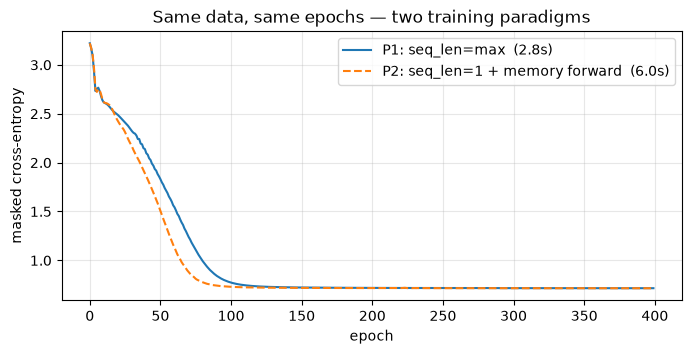

P1 samples: Vera, Elsa, Maria, Marco, Violet, Olivia, Elizabeth, Benjamin
P2 samples: Elisa, Ana, Camila, Pablo, Harper, Harper, Alexander, Sophia


In [99]:
import time

# ---- shared setup (both paradigms) ----
X, Y, lengths = X.to(device), Y.to(device), lengths.to(device)
# build a mask that is True for REAL positions and False for padding
mask = torch.arange(maxlen, device=device)[None, :] < lengths[:, None]   # (names, maxlen)
EPOCHS = 400

def masked_loss(logits, Y, mask):
    # cross-entropy expects (N*maxlen, VOCAB) vs (N*maxlen,)
    lp = F.cross_entropy(logits.reshape(-1, VOCAB), Y.reshape(-1),
                         reduction="none").reshape(Y.shape)
    return (lp * mask).sum() / mask.sum()              # average over REAL positions only

def train_paradigm_1(epochs=EPOCHS, lr=5e-3):
    '''Paradigm 1: ONE model(X) call per epoch -- nn.LSTM loops over time internally (full BPTT).'''
    torch.manual_seed(0)
    m = CharGenerator(VOCAB).to(device)
    opt = torch.optim.Adam(m.parameters(), lr=lr)
    curve = []
    for _ in range(epochs):
        m.train(); opt.zero_grad()
        logits, _ = m(X)                               # (N, maxlen, VOCAB) in one shot; we don't need
                                                       # the returned hidden for training, only for generation
        loss = masked_loss(logits, Y, mask)
        loss.backward(); opt.step()                    # gradient flows through ALL steps
        curve.append(loss.item())
    return m, curve

def train_paradigm_2(epochs=EPOCHS, lr=5e-3):
    '''Paradigm 2: maxlen one-to-one calls per epoch -- WE thread hidden, detach() cuts gradients.'''
    torch.manual_seed(0)
    m = CharGenerator(VOCAB).to(device)
    opt = torch.optim.Adam(m.parameters(), lr=lr)
    curve = []
    for _ in range(epochs):
        m.train(); opt.zero_grad()
        hidden = None                                  # blank memory at the start of each name
        step_logits = []
        for t in range(maxlen):                        # <-- the Python loop that makes this SLOW
            xt = X[:, t:t+1]                           # (N, 1): ONE char of every name
            logits, hidden = m(xt, hidden)             # memory forwarded to the next step...
            hidden = tuple(h.detach() for h in hidden) # ...but detach() CUTS the gradient here (the scissors)
            step_logits.append(logits)
        logits = torch.cat(step_logits, dim=1)         # (N, maxlen, VOCAB) -- same shape as paradigm 1
        loss = masked_loss(logits, Y, mask)
        loss.backward(); opt.step()                    # gradient reaches only INSIDE each step
        curve.append(loss.item())
    return m, curve

t0 = time.time(); model_p1, curve_p1 = train_paradigm_1(); time_p1 = time.time() - t0
t0 = time.time(); model_p2, curve_p2 = train_paradigm_2(); time_p2 = time.time() - t0

print(f"Paradigm 1 (seq_len=max)          : {time_p1:5.1f}s | final loss {curve_p1[-1]:.3f}")
print(f"Paradigm 2 (seq_len=1 + forward)  : {time_p2:5.1f}s | final loss {curve_p2[-1]:.3f}")
print(f"-> Paradigm 2 is {time_p2/time_p1:.1f}x slower, with only {maxlen} steps per name (the gap grows with length)")

plt.figure(figsize=(8, 3.5))
plt.plot(curve_p1, label=f"P1: seq_len=max  ({time_p1:.1f}s)")
plt.plot(curve_p2, label=f"P2: seq_len=1 + memory forward  ({time_p2:.1f}s)", ls="--")
plt.title("Same data, same epochs — two training paradigms")
plt.xlabel("epoch"); plt.ylabel("masked cross-entropy"); plt.legend(); plt.grid(alpha=0.3)
plt.show()

# do they generate equally well? (minimal sampler; the full generate() with temperature
# arrives in Section 6 -- this cell must stay runnable before it)
@torch.no_grad()
def _sample(m, max_len=20):
    m.eval()
    idx, hidden, out = torch.tensor([[stoi["."]]], device=device), None, []
    for _ in range(max_len):
        logits, hidden = m(idx, hidden)                # generation itself IS paradigm 2
        nxt = torch.multinomial(F.softmax(logits[0, -1], dim=-1), 1)
        if nxt.item() == stoi["."]: break
        out.append(itos[nxt.item()]); idx = nxt.view(1, 1)
    return "".join(out)

print("P1 samples:", ", ".join(_sample(model_p1).capitalize() for _ in range(8)))
print("P2 samples:", ", ".join(_sample(model_p2).capitalize() for _ in range(8)))

model = model_p1   # keep the fully-BPTT-trained model -> used for generation in Section 6
# since model_p2 is trained with cut gradients, it cannot learn long-term dependencies and will produce garbage after a few characters.

### Reading the results honestly

**Speed** behaves exactly as the table predicted: Paradigm 2 is **~2–3× slower** here — and that's
with only **10 steps** per name and the whole dataset in one batch. The per-step Python + kernel
launch overhead scales linearly with sequence length, while Paradigm 1's single fused
`nn.LSTM` call barely notices the extra steps. With 100-step sequences the gap becomes brutal,
and on GPU it's even worse (each tiny call can't saturate the device).

**Loss**, however, ends up **almost identical** — didn't we say gradient truncation hurts
learning? Two reasons why the damage doesn't show on *this* toy problem:

1. **Names are short.** Most useful patterns here ("after `q` comes `u`", "`-ia` likes to end a
   name") span 1–3 characters. There's barely any long-range structure for full BPTT to exploit.
2. **The memory *values* still flow.** `detach()` cuts the *learning* signal, not the *information*.
   Because the LSTM's weights are **shared across steps**, the model still learns to *read*
   `h_{t-1}` usefully (that's within-step gradient). What it loses is the ability to learn to
   *write* something at step 1 **because** it will be needed at step 8 — long-range credit
   assignment. With ≤10-char names, that ability is nearly worthless.

> 🔬 **Where the difference would bite:** make the task "generate a valid sentence with matching
> opening/closing quotes 50 tokens apart" and Paradigm 2 (with cut gradients) plateaus, while full
> BPTT keeps improving. This is exactly why real stateful training uses **truncated BPTT with a
> window** (e.g. backprop through 32 steps, detach beyond) — a compromise between the two paradigms:
> `seq_len = k` chunks + memory forwarded between chunks.

**The takeaway table, updated with what we measured:**

| | P1 `seq_len=max` | P2 `seq_len=1` + forward |
|---|---|---|
| wall-clock (400 epochs, 10 steps) | ~1× (baseline) | **~2–3× slower** |
| final training loss | ≈ equal | ≈ equal *(short names → truncation costless)* |
| would win on 100+ step dependencies | ✅ | ❌ (needs a bigger truncation window) |
| memory per step | grows with `seq_len` | constant |

## 6. Generation = feed the model its own output (autoregression)

This is the **one-to-many** payoff, and it runs entirely on **Paradigm 2 mechanics** (one char
per call + memory forward) — here that shape is not a choice but a necessity, because the next
input does not exist until we sample it.

To generate a name:

1. Start with the seed token `.` and an empty memory.
2. The model outputs a probability distribution over the next character.
3. **Sample** a character from that distribution.
4. **Feed that character back in** as the next input, keeping the hidden state.
5. Repeat until the model emits the end token `.`.

Because each new input is the model's *own previous output*, one seed unrolls into a whole
sequence — that feedback is exactly what "autoregressive" means.

### The temperature knob

Instead of always taking the single most-likely character (which produces repetitive, boring
output), we **sample**. **Temperature** `τ` reshapes the distribution before sampling:

- `τ → 0`: nearly always pick the top choice → *safe, repetitive, conservative.*
- `τ = 1`: sample from the model's raw probabilities → *balanced.*
- `τ > 1`: flatten the distribution → *more random, creative, but more typos.*

This single knob is the same "creativity/temperature" setting exposed by modern LLM APIs.

### Carrying `hidden` in the generation loop

`generate()` below is the Paradigm 2 chain from Section 4, doing the job where it has no
substitute. Three details to keep in view while reading the code:

- **`hidden = None` to start** — blank memory, nothing read yet (the `h0 = 0` of the diagrams).
- **`logits, hidden = model(idx, hidden)` on every iteration** — reassigning `hidden` threads the
  SAME memory into the next call. Drop that, and every call would start blank: the model would see
  a single character with no context (amnesia at every step).
- **`idx` is only the newest character** — the whole prefix lives *inside* `hidden`. We never
  re-feed the earlier characters.

```
 hidden=None ─► model('.', hidden) ─► ('o', hidden) ─► model('o', hidden) ─► ('l', hidden) ─► …
                      │  ▲                                    │  ▲
                      └──┘ carry the SAME memory forward ─────┘  (without this: amnesia each step)
```

One difference vs. *training* with Paradigm 2: **no `detach()` here** — we are not learning
(`@torch.no_grad()`), so there is no gradient to cut.


In [93]:
@torch.no_grad()
def generate(model, temperature=1.0, max_len=20):
    '''Generate one name by autoregressive sampling.'''
    model.eval()
    idx = torch.tensor([[stoi["."]]], device=device)   # start with the '.' token, shape (1,1)
    hidden = None                                       # None = blank memory: nothing read yet (like h0=0 in training)
    out_chars = []
    for _ in range(max_len):
        # Feed ONE character, get its prediction AND the updated memory back.
        # We reassign `hidden` every loop so the SAME memory is threaded into the next call --
        # this is what we do by hand here that nn.LSTM did internally during full-sequence training.
        logits, hidden = model(idx, hidden)            # feed ONE char, carry memory forward
        logits = logits[0, -1] / temperature           # last step's scores, temperature-scaled
        probs = F.softmax(logits, dim=-1)              # -> a probability distribution
        nxt = torch.multinomial(probs, num_samples=1)  # SAMPLE (not argmax) -> variety
        if nxt.item() == stoi["."]:                    # end token -> stop
            break
        out_chars.append(itos[nxt.item()])
        idx = nxt.view(1, 1)                            # the sampled char becomes the next input
        # NOTE: idx is only the newest char (not the whole prefix) -- the earlier characters live
        # entirely inside `hidden`. Drop the `hidden` threading and the model would restart blank
        # each step, seeing a single character with no context = amnesia.
    return "".join(out_chars)

print("Generated names at different temperatures:\n")
for temp in [0.5, 0.8, 1.0, 1.3]:
    sample = [generate(model, temperature=temp).capitalize() for _ in range(8)]
    print(f"  temperature {temp}:  {', '.join(sample)}")

Generated names at different temperatures:

  temperature 0.5:  David, Sara, Hazel, Elisa, Oliver, Antonio, Emily, Alvaro
  temperature 0.8:  Ana, Aurora, Antonio, Isabella, Ana, Valentina, Olivia, Jorge
  temperature 1.0:  Isabella, Carmen, Marta, David, Dario, Ava, Javier, Logan
  temperature 1.3:  Laura, Camila, Luis, Stella, David, Clara, Raul, Alba


Notice the trend: **low temperature** gives safe, name-like (sometimes repetitive) outputs that
lean on the most common patterns; **high temperature** gets more adventurous and occasionally
produces unpronounceable strings. Some generated names will accidentally match the training set —
that's expected with such a tiny corpus.

Let's quantify how many generated names are **new** (not in the training list) vs. memorized.

In [94]:
train_set = set(names)
generated = [generate(model, temperature=1.0) for _ in range(200)]
novel = [g for g in generated if g and g not in train_set]
print(f"Of 200 generated names, {len(novel)} are NEW (not in the training set).")
print("A sample of novel inventions:")
print("  ", ", ".join(sorted(set(g.capitalize() for g in novel))[:20]))

Of 200 generated names, 2 are NEW (not in the training set).
A sample of novel inventions:
   Andgel, Camilia


## 7. Where this scales to

The exact machinery here — **tokens → embeddings → recurrent/attention model → next-token
distribution → sample → feed back** — is the blueprint for all modern generative text models:

- Swap **characters** for **word-pieces (subword tokens)**.
- Swap the **LSTM** for a **Transformer** (better at very long context, and parallelizable in
  training).
- Train on **billions** of tokens instead of ~90 names.

…and you have the essence of a large language model. Everything else is scale, engineering, and
alignment. Understanding this small example means you understand the core loop of generative AI.

> 🧠 **RNN vs Transformer for generation:** Transformers dominate large-scale text. But RNNs
> (LSTM/GRU) are still competitive and often *preferred* for **streaming, low-latency, on-device,
> or small-data** generation, because they process one step at a time with fixed memory cost.

## 8. Recap & what's next

- **One-to-many** generation = autoregression: sample a token, **feed it back**, repeat.
- We **train** as many-to-many (predict next char everywhere) but **generate** one-to-many.
- **Embeddings** turn category ids into learned vectors — the default input layer for tokens.
- **Temperature** trades off safe vs. creative sampling — the same knob modern LLMs expose.

➡️ **Next — the capstone:** `06_energy_sensors_forecasting.ipynb` — a realistic **high-frequency,
multivariate sensor** problem from the **energy industry**: forecast future power output several
steps ahead with a **seq2seq GRU/LSTM**, the many-to-many pattern, evaluated against strong
baselines the way a client would demand.